# 01 - Explorative Datenanalyse: Forex-Daten (Yahoo Finance)

**Ziel:** Forex-Kursdaten von Yahoo Finance laden, erkunden und erste Qualitätsprüfung durchführen.

**Währungspaare:** EUR/USD, EUR/CHF, GBP/USD, CHF/USD

**Datenquelle:** Yahoo Finance (via yfinance Library)

---

## 1. Setup und Imports

In [1]:
# Bibliotheken importieren
import yfinance as yf          # Yahoo Finance API
import pandas as pd            # Datenverarbeitung
import numpy as np             # Numerische Berechnungen
import matplotlib.pyplot as plt # Visualisierung
import seaborn as sns           # Erweiterte Visualisierung
import os                       # Dateipfade

# Darstellung konfigurieren
plt.style.use('seaborn-v0_8')  # Schönerer Plot-Stil
plt.rcParams['figure.figsize'] = (12, 6)  # Standardgrösse für Plots
pd.set_option('display.max_columns', None)  # Alle Spalten anzeigen

print('Setup erfolgreich!')

Setup erfolgreich!


## 2. Daten laden von Yahoo Finance

Wir laden die Forex-Kursdaten für unsere Währungspaare.
Yahoo Finance verwendet das Format `EURUSD=X` für Forex-Paare.

In [2]:
# Konfiguration: Welche Währungspaare und welcher Zeitraum?
CURRENCY_PAIRS = {
    'EURUSD=X': 'EUR/USD',   # Euro zu US-Dollar
    'EURCHF=X': 'EUR/CHF',   # Euro zu Schweizer Franken
    'GBPUSD=X': 'GBP/USD',   # Britisches Pfund zu US-Dollar
}

START_DATE = '2022-01-01'
END_DATE = '2026-03-18'

print(f'Zeitraum: {START_DATE} bis {END_DATE}')
print(f'Währungspaare: {list(CURRENCY_PAIRS.values())}')

Zeitraum: 2022-01-01 bis 2026-03-18
Währungspaare: ['EUR/USD', 'EUR/CHF', 'GBP/USD']


In [3]:
# Daten laden und in einem Dictionary speichern
# Jedes Währungspaar wird separat geladen
forex_data = {}

for yahoo_symbol, pair_name in CURRENCY_PAIRS.items():
    print(f'Lade {pair_name} ({yahoo_symbol})...')
    
    # Daten herunterladen
    ticker = yf.Ticker(yahoo_symbol)
    df = ticker.history(start=START_DATE, end=END_DATE)
    
    # Im Dictionary speichern
    forex_data[pair_name] = df
    
    print(f'  -> {len(df)} Zeilen geladen')

print('\nAlle Daten geladen!')

Lade EUR/USD (EURUSD=X)...
  -> 1092 Zeilen geladen
Lade EUR/CHF (EURCHF=X)...
  -> 1092 Zeilen geladen
Lade GBP/USD (GBPUSD=X)...
  -> 1092 Zeilen geladen

Alle Daten geladen!


## 3. Erste Datenübersicht

Schauen wir uns an, was wir bekommen haben.

In [4]:
# Übersicht für jedes Währungspaar
for pair_name, df in forex_data.items():
    print(f'\n{"=" * 50}')
    print(f'{pair_name}')
    print(f'{"=" * 50}')
    print(f'Shape (Zeilen x Spalten): {df.shape}')
    print(f'Zeitraum: {df.index.min()} bis {df.index.max()}')
    print(f'Spalten: {list(df.columns)}')
    print(f'Datentypen:\n{df.dtypes}')
    print(f'\nErste 3 Zeilen:')
    display(df.head(3))


EUR/USD
Shape (Zeilen x Spalten): (1092, 7)
Zeitraum: 2022-01-03 00:00:00+00:00 bis 2026-03-17 00:00:00+00:00
Spalten: ['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits']
Datentypen:
Open            float64
High            float64
Low             float64
Close           float64
Volume            int64
Dividends       float64
Stock Splits    float64
dtype: object

Erste 3 Zeilen:


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2022-01-03 00:00:00+00:00,1.137385,1.137592,1.128541,1.137346,0,0.0,0.0
2022-01-04 00:00:00+00:00,1.130199,1.132300,1.127345,1.130224,0,0.0,0.0
2022-01-05 00:00:00+00:00,1.128541,1.134559,1.127764,1.128363,0,0.0,0.0



EUR/CHF
Shape (Zeilen x Spalten): (1092, 7)
Zeitraum: 2022-01-03 00:00:00+00:00 bis 2026-03-17 00:00:00+00:00
Spalten: ['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits']
Datentypen:
Open            float64
High            float64
Low             float64
Close           float64
Volume            int64
Dividends       float64
Stock Splits    float64
dtype: object

Erste 3 Zeilen:


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2022-01-03 00:00:00+00:00,1.03721,1.03907,1.03489,1.03717,0,0.0,0.0
2022-01-04 00:00:00+00:00,1.03790,1.03830,1.03349,1.03791,0,0.0,0.0
2022-01-05 00:00:00+00:00,1.03373,1.03840,1.03350,1.03368,0,0.0,0.0



GBP/USD
Shape (Zeilen x Spalten): (1092, 7)
Zeitraum: 2022-01-03 00:00:00+00:00 bis 2026-03-17 00:00:00+00:00
Spalten: ['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits']
Datentypen:
Open            float64
High            float64
Low             float64
Close           float64
Volume            int64
Dividends       float64
Stock Splits    float64
dtype: object

Erste 3 Zeilen:


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2022-01-03 00:00:00+00:00,1.352228,1.353180,1.343274,1.352228,0,0.0,0.0
2022-01-04 00:00:00+00:00,1.348279,1.355675,1.346076,1.348327,0,0.0,0.0
2022-01-05 00:00:00+00:00,1.353052,1.357331,1.352265,1.353143,0,0.0,0.0


## 4. Datenqualitätsprüfung

Wir prüfen:
- Fehlende Werte (NaN)
- Duplikate
- Datentypen
- Statistische Kennzahlen

In [5]:
# Fehlende Werte prüfen
print('FEHLENDE WERTE PRO WÄHRUNGSPAAR')
print('=' * 50)

for pair_name, df in forex_data.items():
    missing = df.isnull().sum()
    missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
    
    print(f'\n{pair_name}:')
    if missing.sum() == 0:
        print('  Keine fehlenden Werte!')
    else:
        for col in df.columns:
            if missing[col] > 0:
                print(f'  {col}: {missing[col]} fehlend ({missing_pct[col]}%)')

FEHLENDE WERTE PRO WÄHRUNGSPAAR

EUR/USD:
  Keine fehlenden Werte!

EUR/CHF:
  Keine fehlenden Werte!

GBP/USD:
  Keine fehlenden Werte!


In [6]:
# Duplikate prüfen (gleiche Datumswerte)
print('DUPLIKATE PRO WÄHRUNGSPAAR')
print('=' * 50)

for pair_name, df in forex_data.items():
    dupes = df.index.duplicated().sum()
    print(f'{pair_name}: {dupes} Duplikate')

DUPLIKATE PRO WÄHRUNGSPAAR
EUR/USD: 0 Duplikate
EUR/CHF: 0 Duplikate
GBP/USD: 0 Duplikate


In [7]:
# Statistische Kennzahlen (Deskriptive Statistik)
for pair_name, df in forex_data.items():
    print(f'\n{"=" * 50}')
    print(f'Deskriptive Statistik: {pair_name}')
    print(f'{"=" * 50}')
    display(df.describe())


Deskriptive Statistik: EUR/USD


,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,1092.000000,1092.000000,1092.000000,1092.000000,1092.0,1092.0,1092.0
mean,1.091057,1.094580,1.087492,1.091055,0.0,0.0,0.0
std,0.048764,0.048302,0.049123,0.048760,0.0,0.0,0.0
min,0.959619,0.967006,0.954016,0.959619,0.0,0.0,0.0
25%,1.061918,1.065862,1.058226,1.061918,0.0,0.0,0.0
50%,1.086142,1.089141,1.083113,1.086142,0.0,0.0,0.0
75%,1.122511,1.125448,1.117518,1.122511,0.0,0.0,0.0
max,1.202270,1.202357,1.192194,1.201764,0.0,0.0,0.0



Deskriptive Statistik: EUR/CHF


,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,1092.000000,1092.000000,1092.000000,1092.000000,1092.0,1092.0,1092.0
mean,0.964160,0.966553,0.961619,0.964164,0.0,0.0,0.0
std,0.033012,0.033390,0.032581,0.033010,0.0,0.0,0.0
min,0.900220,0.902650,0.898120,0.900120,0.0,0.0,0.0
25%,0.937208,0.939490,0.935247,0.937240,0.0,0.0,0.0
50%,0.958740,0.961070,0.956175,0.958740,0.0,0.0,0.0
75%,0.982900,0.985810,0.980400,0.982900,0.0,0.0,0.0
max,1.059760,1.061100,1.054920,1.059400,0.0,0.0,0.0



Deskriptive Statistik: GBP/USD


,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,1092.000000,1092.000000,1092.000000,1092.000000,1092.0,1092.0,1092.0
mean,1.273346,1.277667,1.268720,1.273345,0.0,0.0,0.0
std,0.057772,0.056878,0.058760,0.057777,0.0,0.0,0.0
min,1.072846,1.083541,1.037904,1.072754,0.0,0.0,0.0
25%,1.238459,1.242854,1.233665,1.238287,0.0,0.0,0.0
50%,1.270535,1.273674,1.266737,1.270470,0.0,0.0,0.0
75%,1.321008,1.325535,1.316283,1.321008,0.0,0.0,0.0
max,1.382552,1.384677,1.375194,1.382533,0.0,0.0,0.0


## 5. Visualisierung

### 5.1 Kursverlauf (Close-Preis)

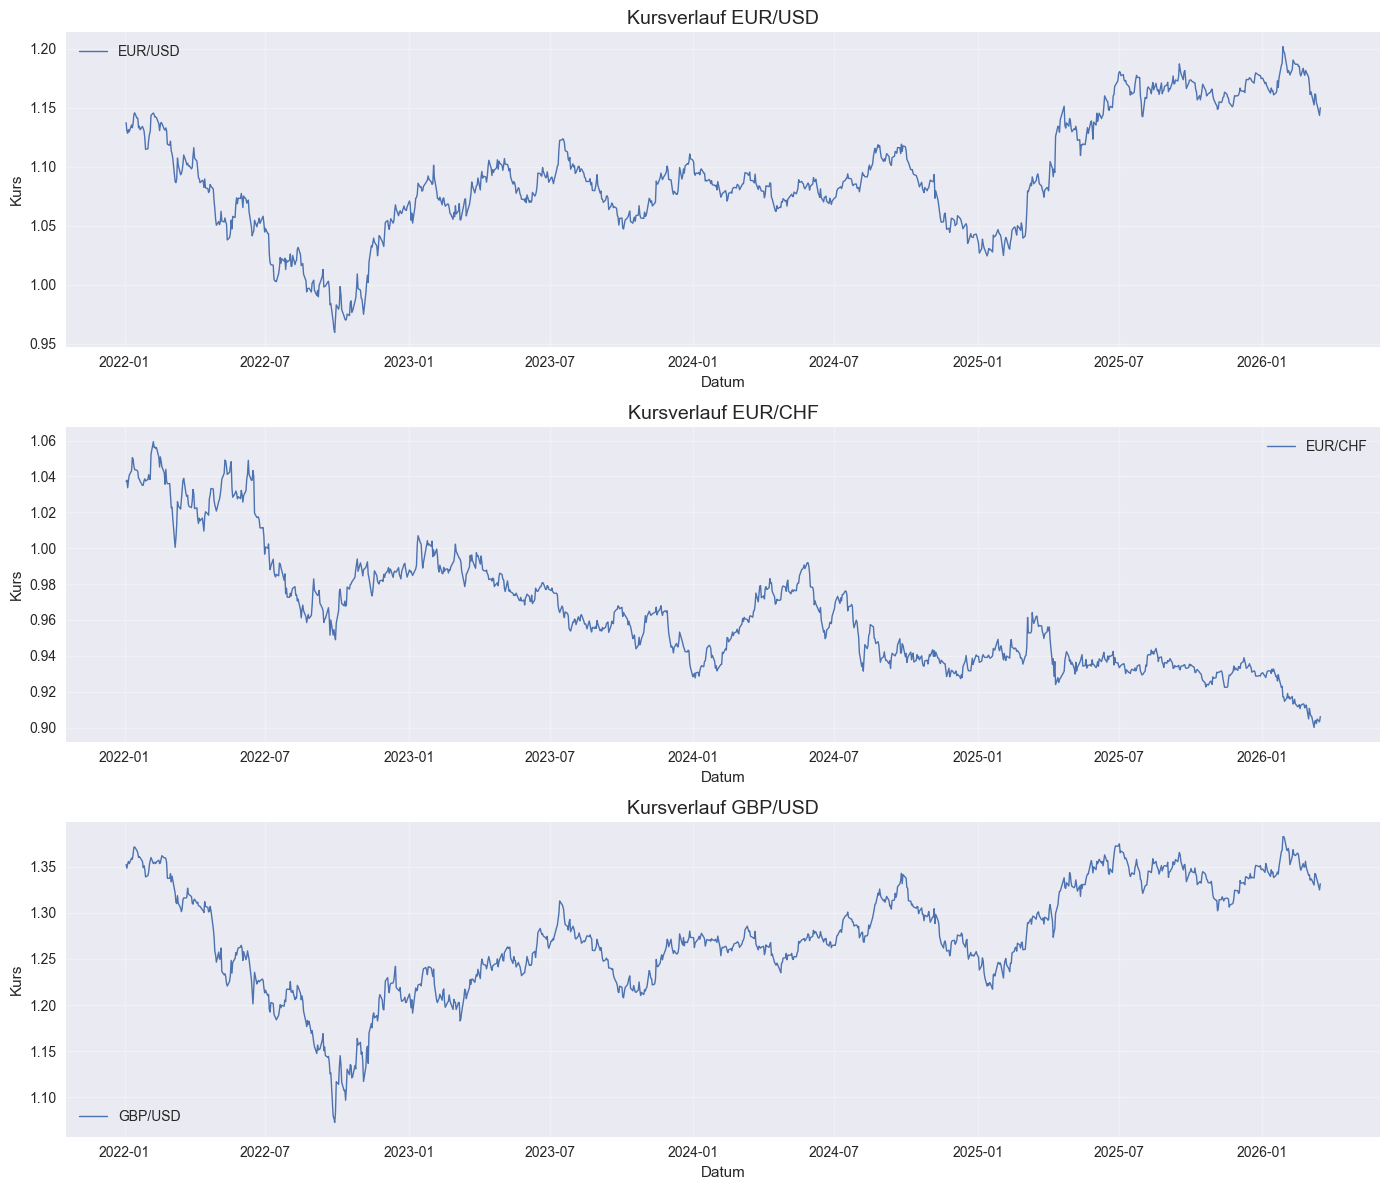

In [8]:
# Kursverlauf für alle Währungspaare plotten
fig, axes = plt.subplots(len(forex_data), 1, figsize=(14, 4 * len(forex_data)))

# Falls nur ein Paar, axes in Liste umwandeln
if len(forex_data) == 1:
    axes = [axes]

for ax, (pair_name, df) in zip(axes, forex_data.items()):
    ax.plot(df.index, df['Close'], label=pair_name, linewidth=1)
    ax.set_title(f'Kursverlauf {pair_name}', fontsize=14)
    ax.set_xlabel('Datum')
    ax.set_ylabel('Kurs')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 5.2 Verteilung der täglichen Renditen

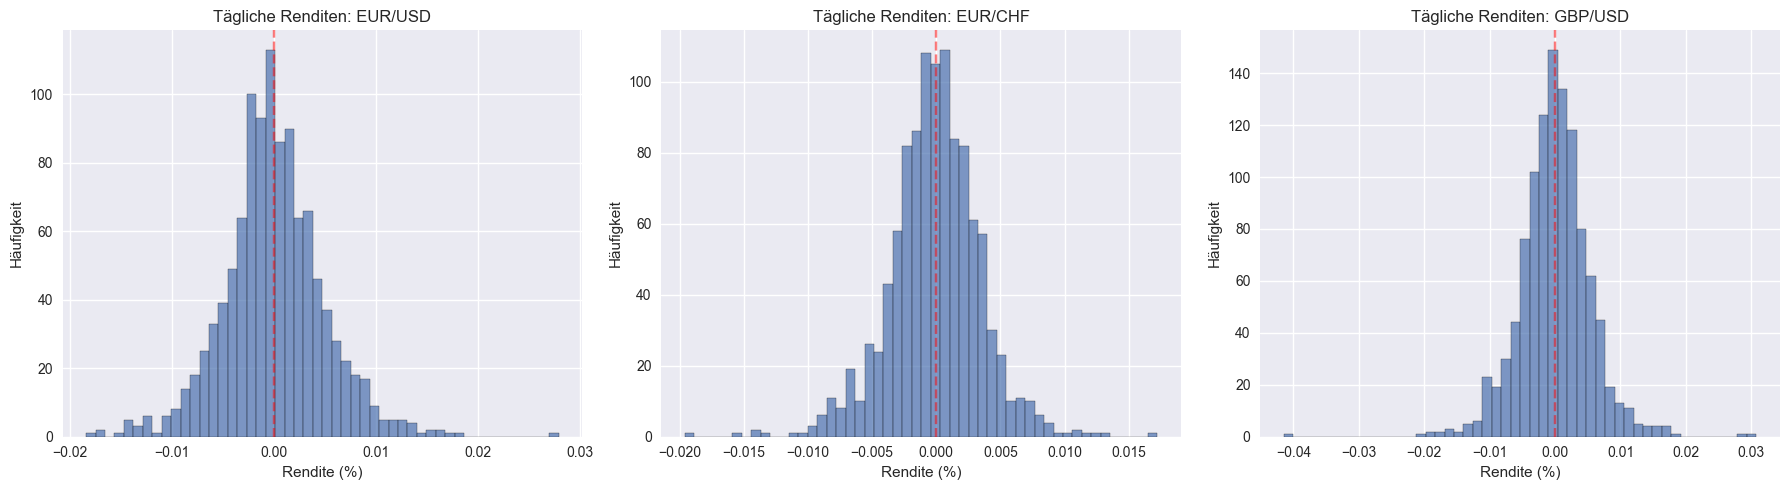

In [9]:
# Tägliche Renditen berechnen und Verteilung anzeigen
fig, axes = plt.subplots(1, len(forex_data), figsize=(6 * len(forex_data), 5))

if len(forex_data) == 1:
    axes = [axes]

for ax, (pair_name, df) in zip(axes, forex_data.items()):
    # Tägliche prozentuale Veränderung berechnen
    returns = df['Close'].pct_change().dropna()
    
    ax.hist(returns, bins=50, edgecolor='black', alpha=0.7)
    ax.set_title(f'Tägliche Renditen: {pair_name}', fontsize=12)
    ax.set_xlabel('Rendite (%)')
    ax.set_ylabel('Häufigkeit')
    ax.axvline(x=0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 5.3 Fehlende Tage identifizieren (Wochenenden, Feiertage)

In [10]:
# Lücken in den Daten identifizieren
for pair_name, df in forex_data.items():
    print(f'\n{pair_name}:')
    
    # Differenz zwischen aufeinanderfolgenden Tagen berechnen
    date_diffs = pd.Series(df.index).diff()
    
    # Lücken grösser als 1 Tag (ohne Wochenenden = 3 Tage)
    gaps = date_diffs[date_diffs > pd.Timedelta(days=3)]
    
    if len(gaps) > 0:
        print(f'  {len(gaps)} grössere Lücken gefunden (> 3 Tage):')
        for idx in gaps.index:
            print(f'    {df.index[idx-1].strftime("%Y-%m-%d")} -> {df.index[idx].strftime("%Y-%m-%d")} ({date_diffs[idx].days} Tage)')
    else:
        print('  Keine unerwarteten Lücken gefunden.')


EUR/USD:
  5 grössere Lücken gefunden (> 3 Tage):
    2022-10-28 -> 2022-10-31 (3 Tage)
    2023-10-27 -> 2023-10-30 (3 Tage)
    2024-10-25 -> 2024-10-28 (3 Tage)
    2025-04-17 -> 2025-04-22 (5 Tage)
    2025-10-24 -> 2025-10-27 (3 Tage)

EUR/CHF:
  5 grössere Lücken gefunden (> 3 Tage):
    2022-10-28 -> 2022-10-31 (3 Tage)
    2023-10-27 -> 2023-10-30 (3 Tage)
    2024-10-25 -> 2024-10-28 (3 Tage)
    2025-04-17 -> 2025-04-22 (5 Tage)
    2025-10-24 -> 2025-10-27 (3 Tage)

GBP/USD:
  5 grössere Lücken gefunden (> 3 Tage):
    2022-10-28 -> 2022-10-31 (3 Tage)
    2023-10-27 -> 2023-10-30 (3 Tage)
    2024-10-25 -> 2024-10-28 (3 Tage)
    2025-04-17 -> 2025-04-22 (5 Tage)
    2025-10-24 -> 2025-10-27 (3 Tage)


In [11]:
# Alle fehlenden Tage anzeigen (inkl. Wochenenden und Feiertage)
for pair_name, df in forex_data.items():
    print(f'\n{"=" * 50}')
    print(f'{pair_name}')
    print(f'{"=" * 50}')
    
    # Vollständigen Datumsbereich erstellen (jeden Tag)
    all_days = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')
    
    # Welche Tage fehlen?
    missing_days = all_days.difference(df.index.normalize())
    
    # Wochenenden vs. Wochentage trennen
    missing_weekends = [d for d in missing_days if d.weekday() >= 5]  # 5=Sa, 6=So
    missing_weekdays = [d for d in missing_days if d.weekday() < 5]   # 0=Mo bis 4=Fr
    
    print(f'Gesamte fehlende Tage:     {len(missing_days)}')
    print(f'  davon Wochenenden:       {len(missing_weekends)}')
    print(f'  davon Wochentage:        {len(missing_weekdays)}')
    
    if len(missing_weekdays) > 0:
        print(f'\n  Fehlende Wochentage (Feiertage etc.):')
        for d in missing_weekdays:
            day_name = ['Mo', 'Di', 'Mi', 'Do', 'Fr'][d.weekday()]
            print(f'    {d.strftime("%Y-%m-%d")} ({day_name})')


EUR/USD
Gesamte fehlende Tage:     443
  davon Wochenenden:       438
  davon Wochentage:        5

  Fehlende Wochentage (Feiertage etc.):
    2025-01-01 (Mi)
    2025-04-18 (Fr)
    2025-04-21 (Mo)
    2025-12-25 (Do)
    2026-01-01 (Do)

EUR/CHF
Gesamte fehlende Tage:     443
  davon Wochenenden:       438
  davon Wochentage:        5

  Fehlende Wochentage (Feiertage etc.):
    2025-01-01 (Mi)
    2025-04-18 (Fr)
    2025-04-21 (Mo)
    2025-12-25 (Do)
    2026-01-01 (Do)

GBP/USD
Gesamte fehlende Tage:     443
  davon Wochenenden:       438
  davon Wochentage:        5

  Fehlende Wochentage (Feiertage etc.):
    2025-01-01 (Mi)
    2025-04-18 (Fr)
    2025-04-21 (Mo)
    2025-12-25 (Do)
    2026-01-01 (Do)


## 6. Rohdaten speichern

Die Rohdaten werden unverändert als CSV gespeichert.

In [ ]:
# Rohdaten als CSV speichern
OUTPUT_DIR = '../../data/raw/forex/yahoo'
os.makedirs(OUTPUT_DIR, exist_ok=True)

for pair_name, df in forex_data.items():
    # Dateinamen erstellen (z.B. EUR_USD_2024-01-01_to_2025-12-31.csv)
    safe_name = pair_name.replace('/', '_')
    filename = f'{safe_name}_{START_DATE}_to_{END_DATE}.csv'
    filepath = os.path.join(OUTPUT_DIR, filename)
    
    # Speichern
    df.to_csv(filepath)
    print(f'Gespeichert: {filepath} ({len(df)} Zeilen)')

print('\nAlle Rohdaten gespeichert!')

## 7. Zusammenfassung

### Erkenntnisse aus der EDA:
- **Datenumfang:** (hier Ergebnisse eintragen nach Ausführung)
- **Fehlende Werte:** (hier Ergebnisse eintragen)
- **Duplikate:** (hier Ergebnisse eintragen)
- **Auffälligkeiten:** (hier Ergebnisse eintragen)

### Nächste Schritte:
1. Gleiche Daten von EODHD laden
2. Datenqualität zwischen Yahoo und EODHD vergleichen
3. Daten bereinigen und harmonisieren